In [3]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import numpy as np
import random
import datetime

from deterministic_combined_with_augmentation import DunexDataset
from network import ResNetUNet
import torch
from visualize_dataset import plot_dataset_grid
from loss import calc_loss
import os
import gc
import time


%load_ext autoreload
%autoreload 2

plt.rcParams['image.origin'] = 'lower'  # Set default origin to lower


In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = ResNetUNet(n_class=1)
model = model.to(device)
# model = torch.compile(model)  # Add this after model definition


sequential_transects = 3
samples_per_image = 128
ds = DunexDataset(['cvat_annotations/triplets_fully_labeled/annotations_poly_updated.xml', 
                   'cvat_annotations/additional_data/annotations_poly.xml'],
                  samples_per_image = samples_per_image,
                  use_missing_data=True)
train, val = torch.utils.data.random_split(ds, (80 * samples_per_image, 5 * samples_per_image)) # 257 (* 3) * 32
batch_size = 64

# Should be deterministic, might need to change to add more workers 
dataloaders = {
    'train': DataLoader(train, batch_size=batch_size, shuffle=True),
    'val':   DataLoader(val,   batch_size=batch_size, shuffle=True),
    # 'test':  DataLoader(test,  batch_size=batch_size, shuffle=True),
}



In [ ]:
def benchmark_batch_size(model, dataloader, device, start_size=4, max_size=128, num_trials=3):
    """Benchmark batch sizes while separating data loading and compute time"""
    results = {}
    sample_input, sample_target = next(iter(dataloader))
    
    def measure_times(batch_size, num_iterations=10):
        try:
            # Pre-generate data to eliminate loading time
            inputs = torch.stack([sample_input[0]] * batch_size).to(device)
            targets = torch.stack([sample_target[0]] * batch_size).to(device)
            
            # Warmup
            for _ in range(3):
                with torch.no_grad():
                    _ = model(inputs)
            
            # Measure data transfer time (CPU -> MPS)
            transfer_times = []
            compute_times = []
            
            for _ in range(num_iterations):
                # Measure data transfer
                inputs_cpu = inputs.cpu()
                torch.mps.synchronize()  # Ensure previous operations are complete
                transfer_start = time.time()
                inputs_gpu = inputs_cpu.to(device, non_blocking=True)
                torch.mps.synchronize()  # Wait for transfer to complete
                transfer_end = time.time()
                transfer_times.append(transfer_end - transfer_start)
                
                # Measure compute time
                torch.mps.synchronize()
                compute_start = time.time()
                outputs = model(inputs_gpu)
                loss = outputs.mean()
                loss.backward()
                torch.mps.synchronize()
                compute_end = time.time()
                compute_times.append(compute_end - compute_start)
            
            # Calculate statistics
            avg_transfer = sum(transfer_times) / len(transfer_times)
            avg_compute = sum(compute_times) / len(compute_times)
            examples_per_second = batch_size / avg_compute  # Pure compute throughput
            
            del inputs, targets, outputs, loss, inputs_cpu, inputs_gpu
            if hasattr(torch.mps, 'empty_cache'):
                torch.mps.empty_cache()
            
            return {
                'batch_size': batch_size,
                'transfer_time': avg_transfer,
                'compute_time': avg_compute,
                'examples_per_second': examples_per_second,
                'total_time': avg_transfer + avg_compute
            }
            
        except RuntimeError as e:  # Out of memory
            print(f"OOM at batch size {batch_size}: {str(e)}")
            return None
    
    current_size = start_size
    while current_size <= max_size:
        # Run multiple trials
        trial_results = []
        for trial in range(num_trials):
            result = measure_times(current_size)
            if result is None:
                return results
            trial_results.append(result)
        
        # Average the trials
        avg_result = {
            'batch_size': current_size,
            'transfer_time': sum(r['transfer_time'] for r in trial_results) / num_trials,
            'compute_time': sum(r['compute_time'] for r in trial_results) / num_trials,
            'examples_per_second': sum(r['examples_per_second'] for r in trial_results) / num_trials,
            'total_time': sum(r['total_time'] for r in trial_results) / num_trials
        }
        
        results[current_size] = avg_result
        print(f"Batch size {current_size}:")
        print(f"  Transfer time: {avg_result['transfer_time']*1000:.2f}ms")
        print(f"  Compute time: {avg_result['compute_time']*1000:.2f}ms")
        print(f"  Examples/second: {avg_result['examples_per_second']:.1f}")
        
        current_size *= 2
    
    return results

# Visualization function
def plot_benchmark_results(results):
    sizes = [r['batch_size'] for r in results.values()]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot times
    ax1.plot([r['transfer_time']*1000 for r in results.values()], 
             label='Transfer Time (ms)', marker='o')
    ax1.plot([r['compute_time']*1000 for r in results.values()], 
             label='Compute Time (ms)', marker='o')
    ax1.set_xlabel('Batch Size')
    ax1.set_ylabel('Time (ms)')
    ax1.set_xticks(range(len(sizes)))
    ax1.set_xticklabels(sizes)
    ax1.legend()
    ax1.grid(True)
    ax1.set_title('Transfer vs Compute Time')
    
    # Plot throughput
    ax2.plot([r['examples_per_second'] for r in results.values()], 
             label='Examples/Second', marker='o')
    ax2.set_xlabel('Batch Size')
    ax2.set_ylabel('Examples/Second')
    ax2.set_xticks(range(len(sizes)))
    ax2.set_xticklabels(sizes)
    ax2.legend()
    ax2.grid(True)
    ax2.set_title('Training Throughput')
    
    plt.tight_layout()
    plt.show()

# Usage
model.train()  # Ensure model is in training mode
results = benchmark_batch_size(model, dataloaders['train'], device)
plot_benchmark_results(results)

In [ ]:
batch_size=32
dataloaders = {
    'train': DataLoader(train, 
                       batch_size=batch_size,
                       shuffle=True,
                       num_workers=2,  # Use 2 workers since you're on MacBook
                       pin_memory=True,
                       persistent_workers=True),
    'val': DataLoader(val, 
                     batch_size=batch_size,
                     shuffle=True,
                     num_workers=2,
                     pin_memory=True,
                     persistent_workers=True)
}


In [ ]:
def profile_training(model, dataloader, optimizer, num_steps=50):
    """Profile training with focus on key operations"""
    print("Profiling training loop...")
    
    batch_times = []
    operation_times = defaultdict(list)
    
    with torch.profiler.profile(
        activities=[torch.profiler.ProfilerActivity.CPU],
        schedule=torch.profiler.schedule(
            wait=2,
            warmup=2, 
            active=num_steps,
            repeat=1),
        record_shapes=True,
        profile_memory=True,
        with_stack=True,
    ) as prof:
        model.train()
        
        for idx, (inputs, labels) in enumerate(dataloader):
            if idx >= num_steps + 4:
                break
                
            batch_start = time.time()
            
            # Track data transfer time
            transfer_start = time.time()
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            operation_times['data_transfer'].append(time.time() - transfer_start)
            
            # Track forward pass
            forward_start = time.time()
            outputs = model(inputs)
            operation_times['forward'].append(time.time() - forward_start)
            
            # Track loss computation
            loss_start = time.time()
            loss = calc_loss(outputs, labels, defaultdict(float), 0)
            operation_times['loss'].append(time.time() - loss_start)
            
            # Track backward pass
            backward_start = time.time()
            loss.backward()
            operation_times['backward'].append(time.time() - backward_start)
            
            # Track optimizer step
            optim_start = time.time()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
            operation_times['optimizer'].append(time.time() - optim_start)
            
            batch_times.append(time.time() - batch_start)
            prof.step()
    
    # Print analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    
    # Overall timing
    batch_times = np.array(batch_times[4:])  # Skip warmup
    print(f"\nBatch Statistics:")
    print(f"Average batch time: {batch_times.mean()*1000:.2f} ms")
    print(f"Throughput: {1/batch_times.mean():.2f} batches/second")
    print(f"Std dev: {batch_times.std()*1000:.2f} ms")
    
    # Operation breakdown
    print(f"\nOperation Time Breakdown:")
    for op, times in operation_times.items():
        times = np.array(times[4:])  # Skip warmup
        percentage = (times.mean() / batch_times.mean()) * 100
        print(f"{op:15s}: {times.mean()*1000:6.2f} ms ({percentage:5.1f}%)")
    
    # Memory analysis
    print(f"\nMemory Analysis:")
    print(prof.key_averages().table(
        sort_by="self_cpu_memory_usage",
        row_limit=5))
    
    return prof, batch_times, operation_times

# Run profiling with optimization suggestions
prof, batch_times, op_times = profile_training(model, dataloaders['train'], optimizer_ft, num_steps=50)

# Visualize timing breakdown
ops = list(op_times.keys())
times = [np.mean(op_times[op]) for op in ops]

plt.figure(figsize=(10, 5))
plt.bar(ops, times)
plt.title('Operation Time Breakdown')
plt.ylabel('Time (seconds)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# ---------------------------

In [10]:
from collections import defaultdict
import torch.nn.functional as F
import torch
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy
from tqdm import tqdm
import gc
import os
import signal
import datetime
from contextlib import contextmanager

@contextmanager
def dataloader_manager(dataloaders):
    """Context manager to properly handle dataloader cleanup"""
    try:
        yield dataloaders
    finally:
        # Ensure proper cleanup of workers
        for phase in dataloaders:
            if hasattr(dataloaders[phase], '_iterator'):
                iterator = dataloaders[phase]._iterator
                if iterator is not None:
                    iterator._shutdown_workers()

def print_metrics(metrics, epoch_samples, phase):
    outputs = []
    for k in metrics.keys():
        outputs.append("{}: {:4f}".format(k, metrics[k] / epoch_samples))
    print("{}: {}".format(phase, ", ".join(outputs)))

def train_model(model, optimizer, scheduler, dataloaders, device, start_epoch=0, num_epochs=200):
    l = []
    validation_metrics = defaultdict(list)
    train_metrics = defaultdict(list)
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10
    last_checkpoint = None

    # Wrap dataloader usage in context manager
    with dataloader_manager(dataloaders):
        try:
            for epoch in range(start_epoch, num_epochs):
                since = time.time()

                for phase in ['train', 'val']:
                    lr = 0
                    if phase == 'train':
                        for param_group in optimizer.param_groups:
                            lr = param_group['lr']
                        model.train()
                    else:
                        model.eval()

                    metrics = defaultdict(float)
                    epoch_samples = 0

                    with tqdm(dataloaders[phase], desc=f'epoch:{epoch} - {phase} -  lr:{lr}') as pbar:
                        for inputs, labels in pbar:
                            try:
                                inputs = inputs.to(device)
                                labels = labels.to(device)
                                
                                optimizer.zero_grad()

                                with torch.set_grad_enabled(phase == 'train'):
                                    outputs = model(inputs)
                                    loss = calc_loss(outputs, labels, metrics, epoch, 
                                                   start_boundary_epoch=num_epochs)

                                    if phase == 'train':
                                        loss.backward()
                                        optimizer.step()
                                        scheduler.step()
                                
                                epoch_samples += inputs.size(0)
                                pbar.set_postfix({'loss': loss.item()})

                            except Exception as e:
                                print(f"Error processing batch: {e}")
                                continue

                    # Update metrics
                    if epoch_samples > 0:  # Only update if we processed any samples
                        if phase == 'train':
                            train_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                            train_metrics['focal'].append(metrics['focal']/epoch_samples)
                            train_metrics['dice'].append(metrics['dice']/epoch_samples)
                            train_metrics['disc'].append(metrics['disc']/epoch_samples)
                            train_metrics['loss'].append(loss.detach().cpu())
                            
                        if phase == 'val':
                            validation_metrics['boundary_loss'].append(metrics['boundary']/epoch_samples)
                            validation_metrics['focal'].append(metrics['focal']/epoch_samples)
                            validation_metrics['dice'].append(metrics['dice']/epoch_samples)
                            validation_metrics['disc'].append(metrics['disc']/epoch_samples)
                            validation_metrics['loss'].append(loss.detach().cpu())

                        print_metrics(metrics, epoch_samples, phase)
                        epoch_loss = metrics['loss'] / epoch_samples
                        
                        if phase == 'val':
                            l.append(epoch_loss)
                            if epoch_loss < best_loss:
                                best_loss = epoch_loss
                                best_model_wts = copy.deepcopy(model.state_dict())
                                
                                if last_checkpoint is not None and os.path.exists(last_checkpoint):
                                    try:
                                        os.remove(last_checkpoint)
                                    except OSError as e:
                                        print(f"Error removing old checkpoint: {e}")
                                
                                last_checkpoint = f'training_checkpoint_model4_epoch{epoch}_{datetime.date.today().strftime("%Y%m%d")}.pt'
                                torch.save(model.state_dict(), last_checkpoint)

                # Memory cleanup
                gc.collect()
                if hasattr(torch, 'mps'):
                    torch.mps.empty_cache()
                elif hasattr(torch, 'cuda'):
                    torch.cuda.empty_cache()

                time_elapsed = time.time() - since

        except KeyboardInterrupt:
            print("\nTraining interrupted by user. Saving current state...")
            if last_checkpoint is None:
                last_checkpoint = f'interrupted_checkpoint_{datetime.date.today().strftime("%Y%m%d")}.pt'
            torch.save(model.state_dict(), last_checkpoint)
            raise

        finally:
            print('Best val loss: {:4f}'.format(best_loss))
            model.load_state_dict(best_model_wts)

    return model, l, train_metrics, validation_metrics

In [27]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from copy import deepcopy
import matplotlib.pyplot as plt
from lion_pytorch import Lion


def create_test_dataloaders(full_dataset, test_size_factor=0.2, batch_size=8):
    """Create smaller dataloaders for quick testing."""
    total_size = len(full_dataset)
    test_size = int(total_size * test_size_factor)
    
    # Create indices for the subset
    indices = torch.randperm(total_size)[:test_size]
    test_dataset = torch.utils.data.Subset(full_dataset, indices)
    
    train_size = int(0.94 * test_size)
    val_size = test_size - train_size
    
    train_subset, val_subset = torch.utils.data.random_split(
        test_dataset, 
        [train_size, val_size]
    )
    
    
    # Create dataloaders with single worker for testing
    test_dataloaders = {
        'train': DataLoader(
            train_subset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,  # Use 0 workers to avoid multiprocessing issues
            pin_memory=True
        ),
        'val': DataLoader(
            val_subset,
            batch_size=batch_size,
            shuffle=True,
            num_workers=0,
            pin_memory=True
        )
    }
    
    return test_dataloaders


def compare_optimizers(model, dataloaders, device, epochs=50, optimizers_config=None):
    """
    Compare different optimizers on the same model architecture.
    
    Args:
        model: Base model architecture
        dataloaders: Dictionary containing 'train' and 'val' dataloaders
        device: torch device
        epochs: Number of epochs to train
        optimizers_config: List of optimizer configurations to test
    """
       
    results = {}
    
    for config in optimizers_config:
        print(f"\nTraining with {config['name']}...")
        
        # Create a fresh copy of the model
        model_copy = deepcopy(model)
        
        # Initialize optimizer
        optimizer = config['optimizer'](
            filter(lambda p: p.requires_grad, model_copy.parameters()),
            **config['params']
        )
        
        # Initialize scheduler
        scheduler_params = config['scheduler_params'].copy()
        scheduler_params.update({
            'optimizer': optimizer,
            'epochs': epochs,
            'steps_per_epoch': len(dataloaders['train'])
        })
        scheduler = config['scheduler'](**scheduler_params)
        
        # Train model
        trained_model, loss_history, train_metrics, val_metrics = train_model(
            model_copy,
            optimizer,
            scheduler,
            dataloaders,
            device,
            start_epoch=0,
            num_epochs=epochs
        )
        
        results[config['name']] = {
            'model': trained_model,
            'train_metrics': train_metrics,
            'val_metrics': val_metrics
        }
    
    # Plot comparison
    plt.figure(figsize=(15, 5))
    
    # Training loss
    plt.subplot(1, 2, 1)
    for name, result in results.items():
        plt.plot(result['train_metrics']['loss'], label=f'{name} (train)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Comparison')
    plt.legend()
    
    # Validation loss
    plt.subplot(1, 2, 2)
    for name, result in results.items():
        plt.plot(result['val_metrics']['loss'], label=f'{name} (val)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Validation Loss Comparison')
    plt.legend()
    
    plt.tight_layout()
    
    return results


def quick_optimizer_test(model, full_dataset, test_epochs=1):
    """
    Run a quick comparison of optimizers on a subset of data.
    """
    # Create smaller test dataloaders
    test_dataloaders = create_test_dataloaders(
        full_dataset=full_dataset,
        test_size_factor=0.1,  # Use 10% of data
        batch_size=32  # Smaller batch size for quicker iterations
    )
    
    
    
    # Basic optimizer configurations for testing
    test_configs = [
        {
            'name': 'Adam',
            'optimizer': optim.Adam,
            'params': {'lr': 5e-4},  # Lower base learning rate
            'scheduler': OneCycleLR,
            'scheduler_params': {
                'max_lr': 2e-3,      # Lower max learning rate
                'div_factor': 5,     # Less aggressive warmup
                'final_div_factor': 50,  # Less aggressive cooldown
                'pct_start': 0.4,    # Longer warmup period
                'anneal_strategy': 'cos'  # Cosine annealing for smoother transitions
            }
        },
        {
            'name': 'AdamW',
            'optimizer': optim.AdamW,
            'params': {'lr': 5e-4, 'weight_decay': 0.005},  # Lower weight decay
            'scheduler': OneCycleLR,
            'scheduler_params': {
                'max_lr': 2e-3,
                'div_factor': 5,
                'final_div_factor': 50,
                'pct_start': 0.4,
                'anneal_strategy': 'cos'
            }
        },
        {
            'name': 'Lion',
            'optimizer': Lion,
            'params': {'lr': 5e-5},  # Lion typically needs lower learning rates
            'scheduler': OneCycleLR,
            'scheduler_params': {
                'max_lr': 2e-4,
                'div_factor': 5,
                'final_div_factor': 50,
                'pct_start': 0.4,
                'anneal_strategy': 'cos'
            }
        },
        {
            'name': 'Adam_Cosine',
            'optimizer': optim.Adam,
            'params': {'lr': 5e-4},
            'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR,  # Try pure cosine instead of OneCycle
            'scheduler_params': {
            'T_max': test_epochs,
            'eta_min': 1e-6
            }
        },
        {
            'name': 'RAdam',
            'optimizer': optim.RAdam,
            'params': {'lr': 5e-4},
            'scheduler': OneCycleLR,
            'scheduler_params': {
                'max_lr': 2e-3,
                'div_factor': 5,
                'final_div_factor': 50,
                'pct_start': 0.4,
                'anneal_strategy': 'cos'
            }
        }
        
    ]    
    # Run quick comparison
    results = compare_optimizers(
        model, 
        test_dataloaders, 
        device,
        epochs=test_epochs,
        optimizers_config=test_configs
    )
    
    return results

# Usage example
test_results = quick_optimizer_test(model, ds, test_epochs=15)


Training with Adam...


epoch:0 - train -  lr:0.00039999999999999996:   0%|          | 0/32 [00:00<?, ?it/s]

epoch:0 - train -  lr:0.00039999999999999996: 100%|██████████| 32/32 [00:18<00:00,  1.70it/s, loss=0.439]


train: focal: 0.028179, dice: 0.910555, loss: 0.469367, boundary: 0.000000, disc: 0.000000


epoch:0 - val -  lr:0: 100%|██████████| 3/3 [00:00<00:00,  5.27it/s, loss=0.484]


...

epoch:14 - train -  lr:6.440596921333407e-05: 100%|██████████| 32/32 [00:15<00:00,  2.06it/s, loss=0.188]


train: focal: 0.042614, dice: 0.324668, loss: 0.183641, boundary: 0.000000, disc: 0.000000


epoch:14 - val -  lr:0: 100%|██████████| 3/3 [00:00<00:00,  6.01it/s, loss=0.21] 


val: focal: 0.052453, dice: 0.363084, loss: 0.207769, boundary: 0.000000, disc: 0.000000
0m 16s
Best val loss: 0.207769

Training with Adam_Cosine...


TypeError: CosineAnnealingLR.__init__() got an unexpected keyword argument 'epochs'

In [34]:
import numpy as np
import torch
from torch.optim import Adam
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

class LRFinder:
    """Learning rate finder inspired by fastai's implementation."""
    def __init__(self, model, optimizer, criterion, device):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        
        # Save the initial parameters to reset after lr finding
        self.init_params = [p.clone().detach() for p in model.parameters()]
        
    def range_test(self, dataloader, start_lr=1e-7, end_lr=10, num_iter=100):
        """Explore learning rates from start_lr to end_lr."""
        # Set initial learning rate
        self.optimizer.param_groups[0]['lr'] = start_lr
        
        # Calculate lr multiplication factor
        mult = (end_lr / start_lr) ** (1/num_iter)
        
        # Storage for lr and loss values
        lrs = []
        losses = []
        best_loss = float('inf')
        
        print("Finding optimal learning rate...")
        for batch_idx, (inputs, targets) in enumerate(tqdm(dataloader)):
            if batch_idx >= num_iter:
                break
                
            inputs, targets = inputs.to(self.device), targets.to(self.device)
            
            # Forward pass
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, targets, defaultdict(float))
            
            # Record lr and loss
            curr_lr = self.optimizer.param_groups[0]['lr']
            lrs.append(curr_lr)
            
            # Update loss if it's better
            if loss.item() < best_loss:
                best_loss = loss.item()
            
            # Stop if loss explodes
            if loss.item() > 4 * best_loss:
                break
                
            # Backward pass
            loss.backward()
            self.optimizer.step()
            
            losses.append(loss.item())
            
            # Update learning rate
            self.optimizer.param_groups[0]['lr'] *= mult
            
        return lrs, losses
    
    def plot(self, lrs, losses):
        """Plot learning rate vs loss."""
        plt.figure(figsize=(10, 6))
        plt.semilogx(lrs, losses)
        plt.grid(True)
        plt.xlabel('Learning Rate')
        plt.ylabel('Loss')
        plt.title('Learning Rate vs. Loss')
        
        # Find the learning rate with minimum loss
        min_loss_idx = np.argmin(losses)
        min_lr = lrs[min_loss_idx]
        
        plt.axvline(min_lr, color='r', linestyle='--', alpha=0.5)
        plt.text(min_lr, plt.ylim()[0], f'Min LR: {min_lr:.2e}', rotation=90)
        
        return min_lr

def visualize_scheduler(scheduler, num_epochs, steps_per_epoch):
    """Visualize the learning rate schedule."""
    lrs = []
    for epoch in range(num_epochs):
        for step in range(steps_per_epoch):
            lrs.append(scheduler.get_last_lr()[0])
            scheduler.step()
    
    plt.figure(figsize=(10, 6))
    plt.plot(lrs)
    plt.xlabel('Training Step')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.grid(True)
    
    return lrs

# Function to test both LR finder and scheduler
def validate_lr_and_scheduler(model, criterion, train_dataloader, device, 
                            start_lr=1e-7, end_lr=1, num_iter=100):
    """Run complete learning rate and scheduler validation."""
    # Initialize optimizer for LR finder
    optimizer = Adam(model.parameters(), lr=start_lr)
    
    # Create and run LR finder
    lr_finder = LRFinder(model, optimizer, criterion, device)
    lrs, losses = lr_finder.range_test(train_dataloader, 
                                     start_lr=start_lr, 
                                     end_lr=end_lr, 
                                     num_iter=num_iter)
    
    # Plot LR finder results
    suggested_lr = lr_finder.plot(lrs, losses)
    
    # Test scheduler with found learning rate
    optimizer = Adam(model.parameters(), lr=suggested_lr)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=suggested_lr * 2,
        epochs=10,
        steps_per_epoch=len(train_dataloader),
        pct_start=0.4,
        anneal_strategy='cos'
    )
    
    # Visualize scheduler
    scheduler_lrs = visualize_scheduler(scheduler, 10, len(train_dataloader))
    
    return suggested_lr, lrs, losses, scheduler_lrs

Finding optimal learning rate...


  0%|          | 0/128 [00:00<?, ?it/s]

/Users/mleclair/.pyenv/versions/dunex_pytorch/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Suggested learning rate: 9.33e-03


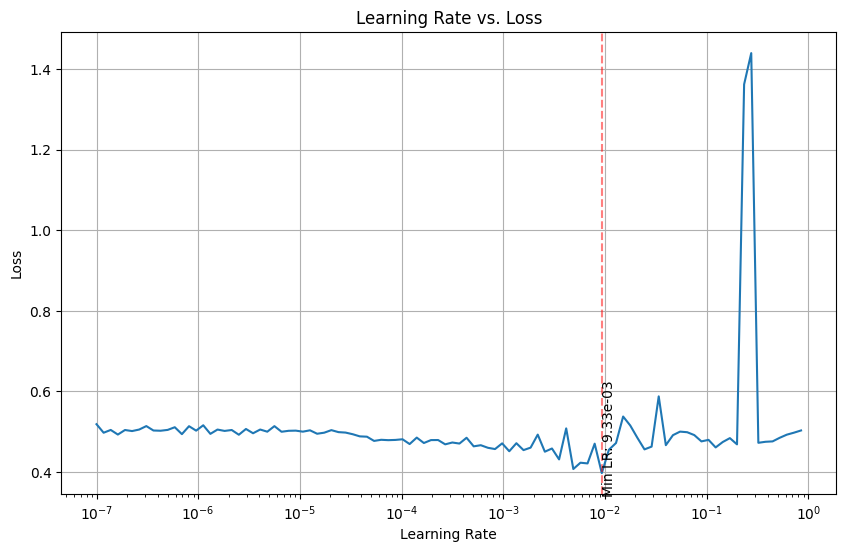

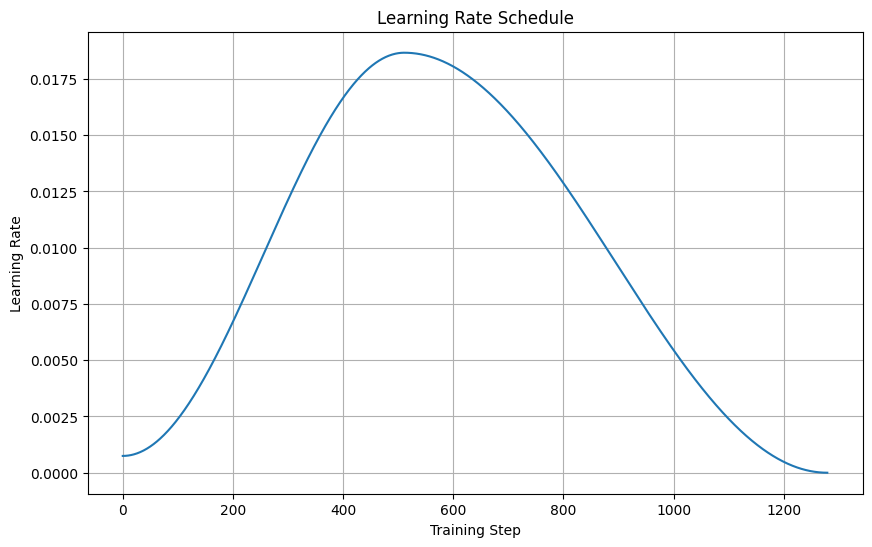

In [35]:
test_dataloader = create_test_dataloaders(ds, test_size_factor=0.1)['train']

# Run the validation
suggested_lr, lrs, losses, scheduler_lrs = validate_lr_and_scheduler(
    model=model,
    criterion=calc_loss,  # Your loss function
    train_dataloader=test_dataloader,
    device=device,
    start_lr=1e-7,
    end_lr=1,
    num_iter=100
)

print(f"Suggested learning rate: {suggested_lr:.2e}")
